# Abbildung der Markenwahrnehmung mit Korrespondenzanalyse (PROC CORRESP)

## Zusammenfassung

Ein Marktforschungsteam führt eine Marke-nach-Attribut-Wahrnehmungsumfrage über vier etablierte Streaming-Media-Marken durch und nutzt **PROC CORRESP**, um die resultierende Kreuztabelle in eine zweidimensionale Wahrnehmungskarte zu überführen. Die Assoziation zwischen Marke x Attribut ist stark und real: Der Chi-Quadrat-Unabhängigkeitstest beträgt **63.15 bei 15 Freiheitsgraden (p < 0.0001)**, mit **Cramérs V = 0.4588**. Die Korrespondenzanalyse komprimiert diese Assoziation in zwei Achsen, die zusammen **100%** der Inertia der Tabelle erklären — **75.0%** auf Dimension 1 und **25.0%** auf Dimension 2 —, sodass die 2-D-Karte eine vollständige, treue Zusammenfassung ist.

Die Karte trennt einen **Premium-Content**-Pol (CineNow, verankert an *Originalserien* und *Inhaltstiefe*) von einem **Value/Reliability**-Cluster (Streamly und BingeBox nahe *Preiswert* und *Zuverlaessig*) und einer **Trendig**-Ecke (PixelPlay nahe *Trendig*). Ein aufstrebender Herausforderer, **NovaCast**, wird anschließend als *ergänzender* (supplementary) Punkt projiziert — er beeinflusst die Achsen nicht — und landet nahe dem Ursprung, leicht zur Trendig-/Bedienkomfort-Seite geneigt, d. h. ein bislang undifferenzierter Neuling.

## Datenquellen

| Datenmenge | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `perception` | 100 (Befragter x Attribut-Assoziationen, Obergrenze im unlizenzierten Modus) | `Brand` (char), `Attribute` (char) | Synthetische Umfrage: Jeder Befragte nennt die Streaming-Marke, die er am stärksten mit jedem von sechs Attributen assoziiert. Markenaffinitäten sind als `RAND("Table", ...)`-Kategorienwahrscheinlichkeiten kodiert, sodass die Kontingenztabelle eine realistische, nicht gleichförmige Assoziation aufweist. |
| `survey_counts` | 24 (4 Marken x 6 Attribute) | `Brand`, `Attribute`, `Count` | Vorab aggregierte Kontingenzzellen aus `perception` via PROC FREQ — die gewichtete Eingabe für den CA-Lauf mit ergänzendem Punkt. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | `OUTC=`-Koordinatendatenmengen, von PROC CORRESP geschrieben; die zweite fügt den projizierten NovaCast-Punkt hinzu und treibt die Wahrnehmungskarte an. |

Etablierte Marken: **Streamly, PixelPlay, CineNow, BingeBox**; Herausforderer **NovaCast** (als ergänzender Punkt projiziert). Attribute: Preiswert, Inhaltstiefe, Bedienkomfort, Originalserien, Zuverlaessig, Trendig. Der Seed `streaminit(20260531)` macht die Daten reproduzierbar.

> **Hinweis zum Stichprobenumfang.** Diese Umgebung läuft unlizenziert, sodass die DATA-Step-Ausgabe auf 100 Beobachtungen begrenzt ist. Die Umfrage ergibt daher eine 4x6-Kontingenztabelle mit insgesamt 100 Befragter-Attribut-Assoziationen — klein, aber mit echter Assoziationsstruktur (Chi-Quadrat p < 0.0001), die die Korrespondenzanalyse sauber zurückgewinnt.

## Was die Korrespondenzanalyse hier leistet

Wenn eine Marken-Tracking-Umfrage Verbraucher fragt, welche Marke sie am stärksten mit jedem von mehreren Attributen assoziieren, ist das Ergebnis eine **Marke x Attribut-Kontingenztabelle**. Die rohen Häufigkeiten sind schwer zu lesen: Jede Marke wird gegen jedes Attribut verglichen, und das Signal ist das *Assoziationsmuster*, nicht die Zellwerte.

Die Korrespondenzanalyse (CA) zerlegt die Chi-Quadrat-Assoziation der Tabelle in einen niedrigdimensionalen Raum, sodass assoziierte Marken und Attribute auf einer Karte nahe beieinander landen. In diesem Notebook:

1. erzeugen wir eine synthetische Wahrnehmungsumfrage für vier Streaming-Marken.
2. betrachten wir die rohe Kontingenzstruktur (und ihr Chi-Quadrat) mit `PROC FREQ`.
3. führen wir `PROC CORRESP` mit vollständiger Diagnostik aus und lesen die tatsächliche Inertia und die Koordinaten.
4. projizieren wir eine aufstrebende Herausforderer-Marke als **ergänzenden** Punkt.
5. zeichnen und interpretieren wir die resultierende Wahrnehmungskarte.

## Schritt 1 — Erzeugung der synthetischen Wahrnehmungsumfrage

Wir simulieren Umfrageteilnehmer. Für jeden Befragten fragen wir für jedes von sechs Attributen: *Welche Marke assoziieren Sie am stärksten mit diesem Attribut?* Jede Marke hat ein eigenes **Affinitätsprofil** — einen Vektor von Kategorienwahrscheinlichkeiten, der an `RAND("Table", ...)` übergeben wird —, sodass zum Beispiel *PixelPlay* zu Trendig tendiert, während *CineNow* zu Inhaltstiefe und Originalserien tendiert. Das erzeugt eine Kontingenztabelle mit echter, nicht gleichförmiger Assoziation, die die CA zurückgewinnen kann. Die Daten sind vollständig synthetisch und über `CALL STREAMINIT` reproduzierbar.

In [1]:
DATEN perception;
    /* Reproduzierbare synthetische Markenwahrnehmungs-Befragung */
    AUFRUFEN streaminit(20260531);

    LÄNGE Brand $9 Attribute $15;
    FELD attrname[6] $15 _temporary_
        ('Preiswert' 'Inhaltstiefe' 'Bedienkomfort'
         'Originalserien' 'Zuverlaessig' 'Trendig');

    n_resp = 400;

    AUSFÜHRUNG respondent = 1 BIS n_resp;
        AUSFÜHRUNG a = 1 BIS 6;
            Attribute = attrname[a];

            /* Markenwahl-Wahrscheinlichkeiten je Merkmal über die
               vier etablierten Marken:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Jede Zeile summiert sich zu ~1 und kodiert die
               Marken-Affinität des Merkmals. */
            WENN      a = 1 DANN b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Preiswert     */
            SONST WENN a = 2 DANN b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Inhaltstiefe  */
            SONST WENN a = 3 DANN b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Bedienkomfort */
            SONST WENN a = 4 DANN b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Originalserien*/
            SONST WENN a = 5 DANN b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Zuverlaessig  */
            SONST              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendig       */

            AUSWÄHLEN (b);
                FALLS (1) Brand = 'Streamly';
                FALLS (2) Brand = 'PixelPlay';
                FALLS (3) Brand = 'CineNow';
                ANDERNFALLS Brand = 'BingeBox';
            ENDE;

            AUSGABE;
        ENDE;
    ENDE;

    BEHALTEN respondent Brand Attribute;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=perception(obs=8) noobs;
    BEZEICHNUNG Brand='Marke' Attribute='Merkmal' respondent='Befragte(r)';
    TITEL 'Auszug aus der synthetischen Wahrnehmungsbefragung';
AUSFÜHREN;

                                   Auszug aus der synthetischen Wahrnehmungsbefragung                                   

Befragte(r)      Marke         Merkmal
          1  BingeBox   Preiswert
          1  BingeBox   Inhaltstiefe
          1  BingeBox   Bedienkomfort
          1  CineNow    Originalserien
          1  Streamly   Zuverlaessig
          1  PixelPlay  Trendig
          2  PixelPlay  Preiswert
          2  CineNow    Inhaltstiefe

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.32 seconds
  cpu   0.32 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Schritt 2 — Betrachtung der rohen Kontingenztabelle

Vor jeder Dimensionsreduktion betrachten wir die Kreuztabelle. `PROC FREQ` liefert die beobachteten Marke x Attribut-Häufigkeiten und den Chi-Quadrat-Unabhängigkeitstest. Ein signifikantes Chi-Quadrat bestätigt, dass es eine Assoziationsstruktur gibt, die abzubilden lohnt — wären Zeilen und Spalten unabhängig, hätte die Korrespondenzanalyse nichts zu zeigen. Wir speichern die Zellhäufigkeiten außerdem in `survey_counts` für den späteren CA-Lauf mit ergänzendem Punkt.

                                       Beobachtete Häufigkeiten: Marke x Merkmal                                        

                                                   The FREQ Procedure

Table of Marke by Merkmal

Marke     | Bedienkomfort |  Inhaltstiefe |Originalserien |     Preiswert |       Trendig |  Zuverlaessig |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             7 |             3 |             1 |             5 |             2 |             6 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             0 |             9 |            14 |             3 |             0 |             2 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             6 |             2 


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


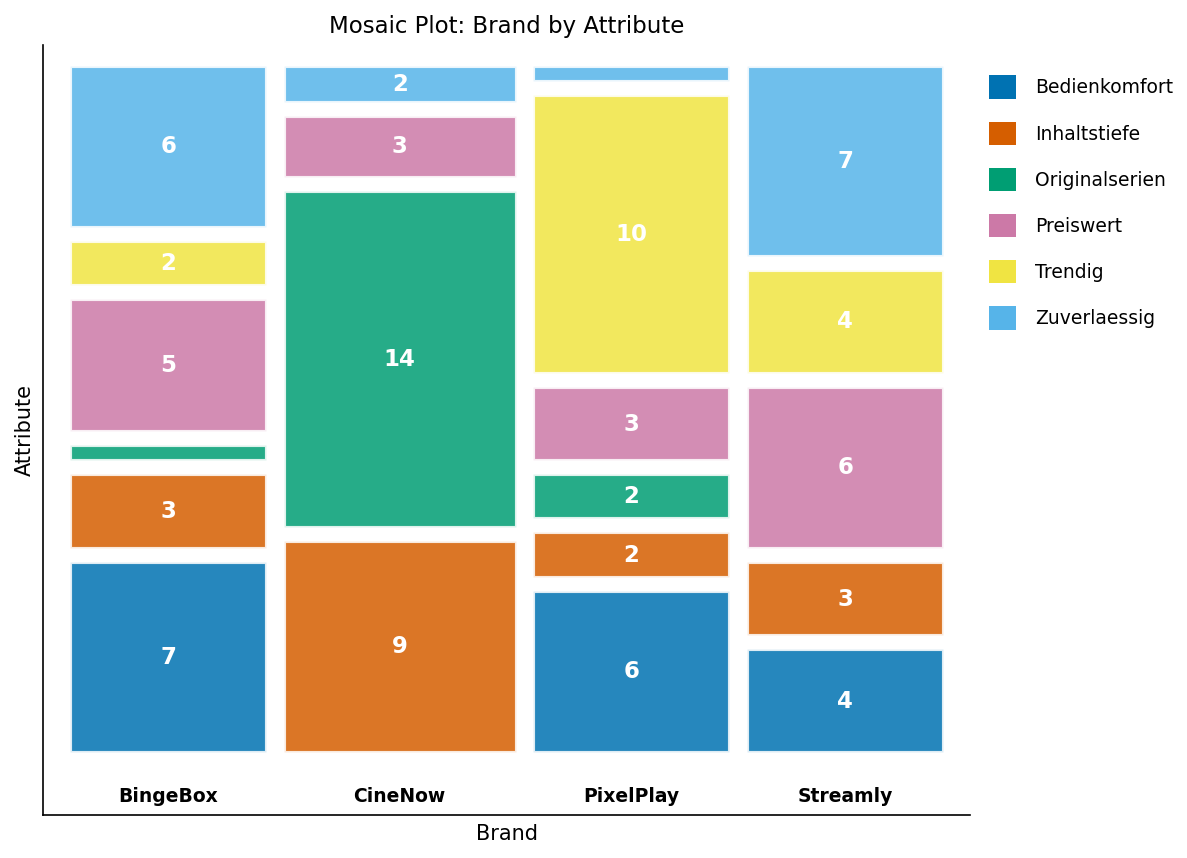

In [2]:
PROZEDUR HÄUFIGKEITEN DATEN=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(UMBENENNEN=(count=Count));
    BEZEICHNUNG Brand='Marke' Attribute='Merkmal';
    TITEL 'Beobachtete Häufigkeiten: Marke x Merkmal';
AUSFÜHREN;

## Schritt 3 — Korrespondenzanalyse aus den Rohdaten

Nun führen wir `PROC CORRESP` direkt auf den Daten auf Befragtenebene aus. `TABLES Brand, Attribute;` bildet die Kontingenztabelle intern (Marken als Zeilen, Attribute als Spalten).

Hier verwendete Optionen:

- `ALL` — gibt die vollständige Diagnostik aus: beobachtete Tabelle, Profile, Erwartungswerte und Chi-Quadrat-Beiträge der Zellen.
- `DIMENS=2` — berechnet die ersten beiden Hauptachsen (eine 2-D-Karte).
- `OUTC=` — schreibt Zeilen- und Spaltenkoordinaten in eine Datenmenge zum Plotten.

Die **Inertia-Zerlegung** sagt uns, wie viel der Gesamtassoziation jede Achse erklärt.

In [3]:
PROZEDUR corresp DATEN=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    BEZEICHNUNG Brand='Marke' Attribute='Merkmal';
    TITEL 'Korrespondenzanalyse: Wahrnehmung von Streaming-Marken';
AUSFÜHREN;

                                       Beobachtete Häufigkeiten: Marke x Merkmal                                        

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marke                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Schritt 4 — Lesen der Koordinaten

Die `OUTC=`-Datenmenge enthält die Achsenkoordinaten (`Dim1`, `Dim2`) für jede Marke und jedes Attribut, gekennzeichnet durch `_TYPE_` (`ROW` für Marken, `COLUMN` für Attribute). Sie numerisch neben der Inertia-Tabelle zu lesen bestätigt die Struktur, die die Karte zeigen wird.

Aus der Ausgabe oben:

- **Dimension 1 (75.0% der Inertia)** ist eine Achse *Premium-Content vs. Mainstream*. *Originalserien* (Dim1 = -1.2037) und *Inhaltstiefe* (-0.5594) liegen am negativen Ende mit **CineNow** (-1.0847); *Trendig* (0.6671), *Bedienkomfort* (0.6150) und *Preiswert* (0.2207) liegen am positiven Ende.
- **Dimension 2 (25.0% der Inertia)** trennt *Zuverlaessig* (Dim2 = 0.5874) und *Preiswert* (0.2542) — die **Streamly** (0.3207) und **BingeBox** (0.3555) nach oben ziehen — von *Trendig* (-0.7003), das **PixelPlay** (-0.6374) nach unten zieht.

In [4]:
PROZEDUR DRUCKEN DATEN=ca_coords noobs;
    VAR _TYPE_ _NAME_ Dim1 Dim2;
    BEZEICHNUNG Dim1='Dimension 1' Dim2='Dimension 2';
    TITEL 'Koordinaten der Zeilen (Marken) und Spalten (Merkmale)';
AUSFÜHREN;

                                 Koordinaten der Zeilen (Marken) und Spalten (Merkmale)                                 

_TYPE_            _NAME_  Dimension 1  Dimension 2
ROW     BingeBox               0.3547       0.3555
ROW     CineNow               -1.0847      -0.0332
ROW     PixelPlay              0.4804      -0.6374
ROW     Streamly               0.4304       0.3207
COLUMN  Bedienkomfort          0.6150      -0.0080
COLUMN  Inhaltstiefe          -0.5594       0.0684
COLUMN  Originalserien        -1.2037      -0.2084
COLUMN  Preiswert              0.2207       0.2542
COLUMN  Trendig                0.6671      -0.7003
COLUMN  Zuverlaessig           0.3183       0.5874




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Schritt 5 — Projektion einer Herausforderer-Marke als ergänzender Punkt

Das Analytics-Team verfügt über Tracking-Daten für einen aufstrebenden Herausforderer, **NovaCast**, möchte aber nicht, dass er die etablierte Wahrnehmungskarte verzerrt. Ein *ergänzender* Punkt wird in den bestehenden CA-Raum projiziert, **ohne zur Achsenberechnung beizutragen**.

Wir hängen einen einzelnen Block von sechs NovaCast-Attributhäufigkeiten (ein zu Trendig / Originalserien tendierender Neuling) an die vorab aggregierte `survey_counts` an, speisen die Häufigkeiten mit `WEIGHT Count` und benennen die **Ebene** `NovaCast` in der `SUPPLEMENTARY`-Anweisung, sodass PROC CORRESP diese Zeile aus der aktiven Tabelle heraushält. Die `OBSERVED`-Option hält die aktive Kontingenztabelle (die vier etablierten Marken, die sich zu 100 summieren) im Blick — man beachte, dass NovaCast **nicht** darin erscheint, was bestätigt, dass es als ergänzend behandelt wurde.

In [5]:
/* Einen sauberen Block mit NovaCast-Zählungen an die aggregierten
   Zellen anfügen. end=last feuert genau einmal, nach der letzten
   survey_counts-Zeile, sodass NovaCast sechs Zeilen beisteuert (eine
   je Merkmal) -- kein duplizierter Block. NovaCast ist ein von
   Trendig / Originalserien getragener Neueinsteiger. */
DATEN survey_counts_sup;
    FESTLEGEN survey_counts ENDE=last;
    AUSGABE;
    WENN last DANN AUSFÜHRUNG;
        Brand='NovaCast'; Attribute='Trendig';         Count=10; AUSGABE;
        Brand='NovaCast'; Attribute='Originalserien';  Count=8;  AUSGABE;
        Brand='NovaCast'; Attribute='Bedienkomfort';   Count=5;  AUSGABE;
        Brand='NovaCast'; Attribute='Inhaltstiefe';    Count=3;  AUSGABE;
        Brand='NovaCast'; Attribute='Preiswert';       Count=4;  AUSGABE;
        Brand='NovaCast'; Attribute='Zuverlaessig';    Count=3;  AUSGABE;
    ENDE;
AUSFÜHREN;

PROZEDUR corresp DATEN=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    GEWICHT Count;
    supplementary NovaCast;
    BEZEICHNUNG Brand='Marke' Attribute='Merkmal';
    TITEL 'Markenwahrnehmung mit NovaCast als ergänzendem Punkt';
AUSFÜHREN;

                                 Koordinaten der Zeilen (Marken) und Spalten (Merkmale)                                 

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Marke                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Schritt 6 — Zeichnen der Wahrnehmungskarte

PROC CORRESP schreibt die symmetrischen Zeilen-/Spaltenkoordinaten in die `OUTC=`-Datenmenge; wir plotten Dimension 2 gegen Dimension 1, um die Karte darzustellen. Wir kennzeichnen jeden Punkt nach **Rolle** — *Marke* (aktive Zeilen), *Merkmal* (Spalten) und *Herausforderer* (die ergänzende NovaCast-Zeile) — und beschriften jeden Marker, sodass die Positionierung direkt aus dem Plot abgelesen wird. Der Herausforderer ist separat eingefärbt, um zu unterstreichen, dass er hineinprojiziert und nicht angepasst wurde.

> **Wie man eine CA-Karte liest.** Eine Marke und ein Attribut, die vom Ursprung aus in dieselbe Richtung (und weit davon entfernt) liegen, sind stark assoziiert; Punkte nahe dem Ursprung sind "durchschnittlich" und schwach differenziert. Da die Dimensionen 1 und 2 zusammen 100% der Inertia dieser Tabelle erfassen, lässt die Karte nichts aus.

                     Wahrnehmungskarte der Streaming-Marken (Dim1 75,0 %, Dim2 25,0 % der Inertia)                      

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Marke    BingeBox      0.3547      0.3555
     Marke     CineNow     -1.0847     -0.0332
     Marke   PixelPlay      0.4804     -0.6374
     Marke    Streamly      0.4304      0.3207
Herausforderer    NovaCast      0.0084     -0.1735
   Merkmal  Bedienkomfort       0.615      -0.008
   Merkmal  Inhaltstiefe     -0.5594      0.0684
   Merkmal  Originalserien     -1.2037     -0.2084
   Merkmal   Preiswert      0.2207      0.2542
   Merkmal     Trendig      0.6671     -0.7003
   Merkmal  Zuverlaessig      0.3183      0.5874

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Wahrnehmungskarte der Streaming-Marken (Dim1 75,0 %, Dim2 25,0 % der Inertia).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


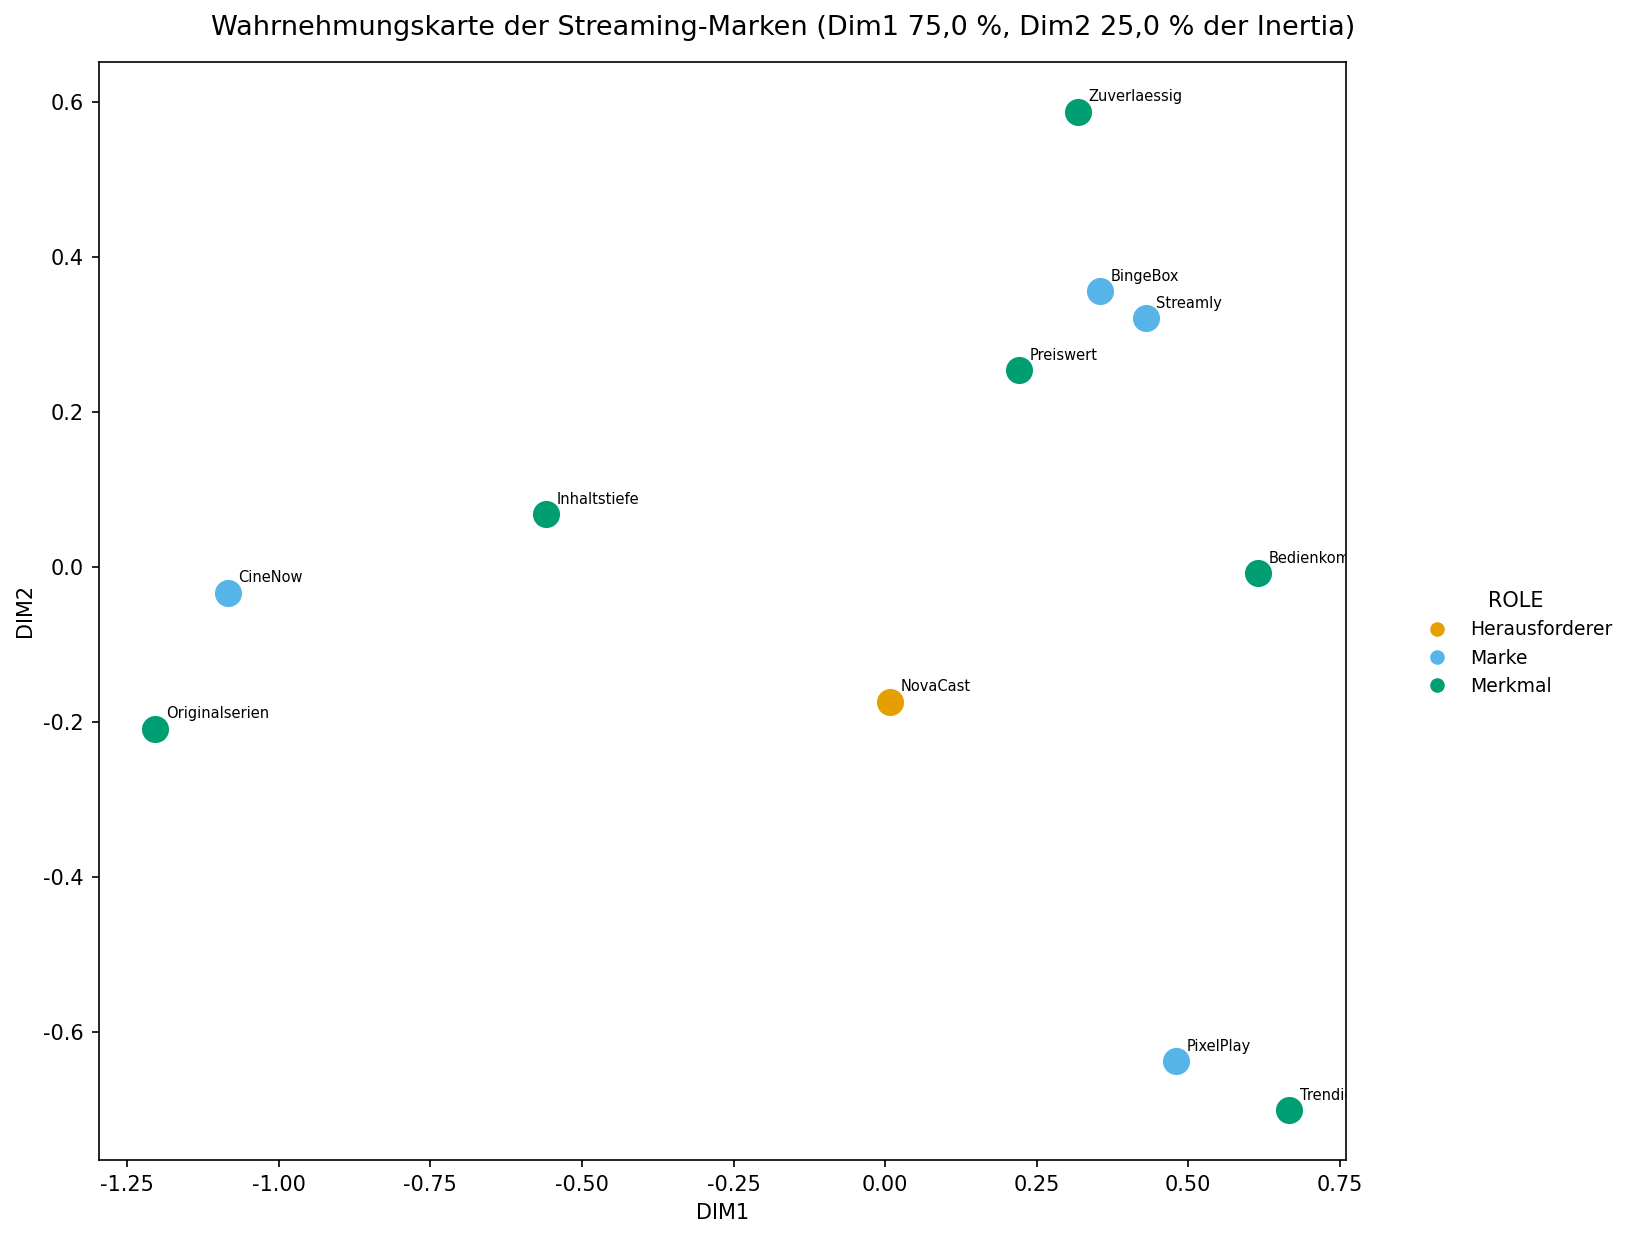

In [6]:
/* Jeden OUTC-Punkt nach Rolle kennzeichnen für eine saubere,
   farbige Legende. Das supplementäre NovaCast wird mit _TYPE_='ROW'
   in OUTC geschrieben, daher behandeln wir es gesondert als
   Herausforderer. */
DATEN ca_map;
    FESTLEGEN ca_coords_sup;
    LÄNGE Role $16;
    WENN _NAME_ = 'NovaCast' DANN Role = 'Herausforderer';
    SONST WENN _TYPE_ = 'ROW' DANN Role = 'Marke';
    SONST Role = 'Merkmal';
    BEHALTEN Role _NAME_ Dim1 Dim2;
AUSFÜHREN;

/* Den Kartentitel global vor der PROC setzen, damit er dieses
   Diagramm betitelt (der globale TITLE steuert die Überschrift
   der ODS-Grafik). */
TITEL 'Wahrnehmungskarte der Streaming-Marken (Dim1 75,0 %, Dim2 25,0 % der Inertia)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP hat in diesem Build keine native ODS-Karte, daher
   rendern wir die symmetrischen Koordinaten mit PROC SGSCATTER,
   das jeden Punkt beschriftet. */
PROZEDUR SGSCATTER DATEN=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
AUSFÜHREN;

ODS GRAPHICS OFF;
TITEL;

## Interpretation der Ergebnisse

**Die Assoziation ist real und vollständig erfasst.** Der Chi-Quadrat-Test (63.15 bei 15 df, p < 0.0001; Cramérs V = 0.4588) verwirft die Unabhängigkeit, und die beiden CA-Dimensionen erklären **100%** der Inertia der Tabelle (75.0% + 25.0%), sodass die Karte unten eine vollständige Zusammenfassung und keine verlustbehaftete Projektion ist.

**Drei Wahrnehmungsterritorien.** Liest man die Koordinaten und die Karte zusammen:

- **Premium-Content (links).** *CineNow* (Dim1 = -1.0847) wird durch *Originalserien* (-1.2037) und *Inhaltstiefe* (-0.5594) weit nach links gezogen — es besitzt die Wahrnehmung der Katalogtiefe.
- **Value & Reliability (oben rechts).** *Streamly* (0.4304, 0.3207) und *BingeBox* (0.3547, 0.3555) gruppieren sich mit *Preiswert* (0.2207, 0.2542) und *Zuverlaessig* (0.3183, 0.5874) — das verlässliche, preiswerte Paar.
- **Trendig (unten rechts).** *PixelPlay* (0.4804, -0.6374) sitzt neben *Trendig* (0.6671, -0.7003) — die jugendliche, angesagte Marke.

**Der ergänzende Herausforderer.** Ohne die Achsen zu beeinflussen projiziert, landet **NovaCast** bei (0.0084, -0.1735) — im Wesentlichen im Ursprung, leicht zur Trendig-/Bedienkomfort-Seite geschoben. Für einen Medienstrategen ist das die Kernaussage: Der Herausforderer hat noch keine unverwechselbare Markenstärke und driftet in PixelPlays Trendig-Territorium, sodass eine differenzierte Positionierung (statt einer Nachahmung) angebracht ist.

**Vorbehalte.** Die Korrespondenzanalyse ist deskriptiv, nicht inferenzstatistisch — Abstände sind näherungsweise und die *Vorzeichen* der Achsen sind willkürlich (eine Spiegelung einer der Achsen ergibt dieselbe Karte). Bei nur 100 Befragter-Attribut-Assoziationen sind zwei Zellen null (CineNow x Bedienkomfort, Streamly x Originalserien), was die Extreme verschärft; eine Produktivstudie würde eine größere Stichprobe erheben. Kombinieren Sie die Karte stets mit der Inertia-Tabelle, um zu bestätigen, wie viel Assoziation die dargestellten Dimensionen erklären.